In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install transformers accelerate torch torchvision pillow

import torch
from PIL import Image
from transformers import Blip2Processor, Blip2ForConditionalGeneration

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)

model.to(device)
model.eval()

print("BLIP-2 loaded!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/122k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 loaded!


In [4]:
def generate_blip_caption(image_path):
    image = Image.open(image_path).convert("RGB")

    prompt = "Question: Describe this scene. Answer:"
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=40,
        do_sample=False
    )

    caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    caption = caption.replace(prompt, "").strip()

    display(image)
    print("BLIP-2 Caption:", caption)

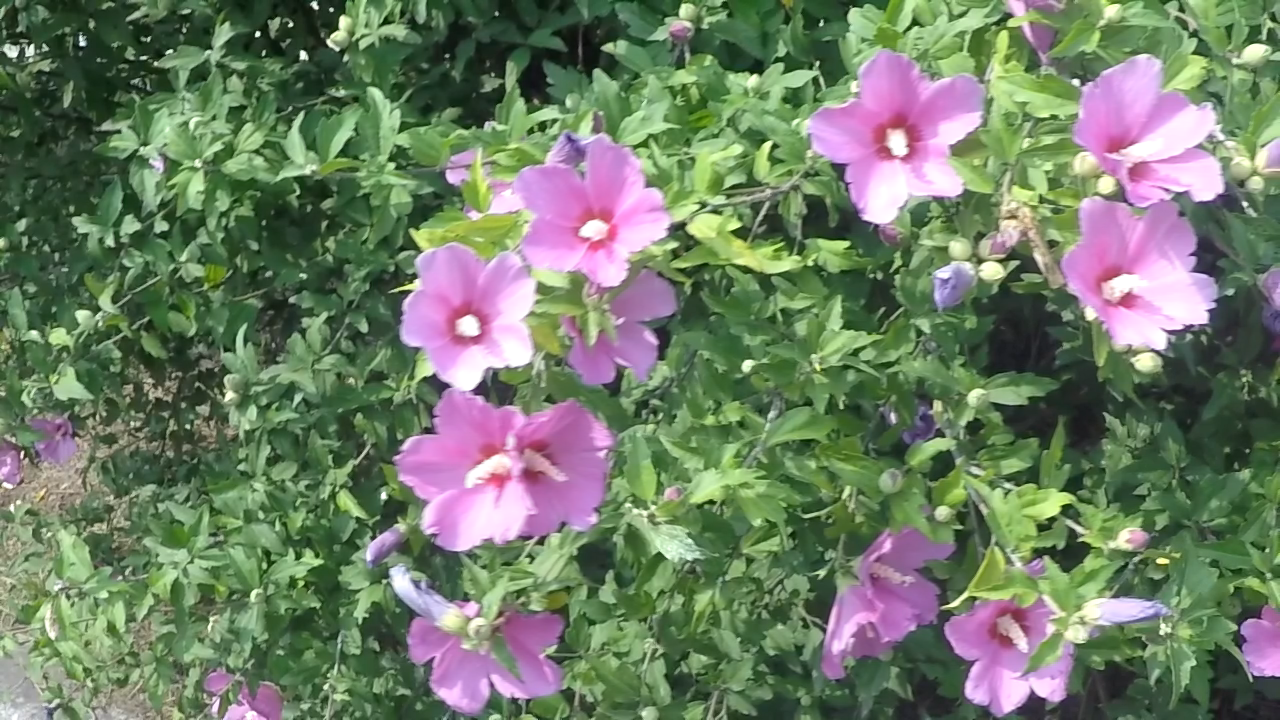

BLIP-2 Caption: This is a pink hibiscus bush in the front yard of a home in the city of miami, florida


In [5]:
blur_path = "/content/drive/MyDrive/VLU-Net-V2/datasets/deblurring_datasets/GoPro/test/blur/1001.png"
generate_blip_caption(blur_path)

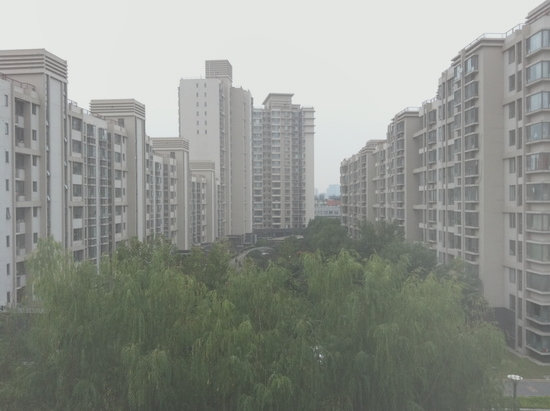

BLIP-2 Caption: a residential area in shanghai


In [6]:
haze_path = "/content/drive/MyDrive/VLU-Net-V2/datasets/dehazing_datasets/SOTS_outdoors/hazy/0051_0.8_0.2.jpg"
generate_blip_caption(haze_path)

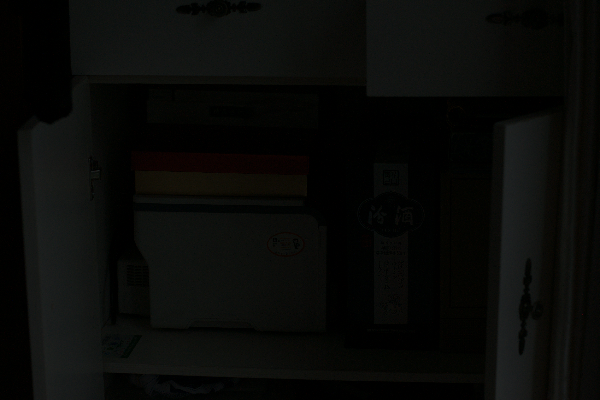

BLIP-2 Caption: A dark room with a light on the desk


In [7]:
lowlight_path = "/content/drive/MyDrive/VLU-Net-V2/datasets/delowlight_datasets/LoL/eval15/low/55.png"
generate_blip_caption(lowlight_path)

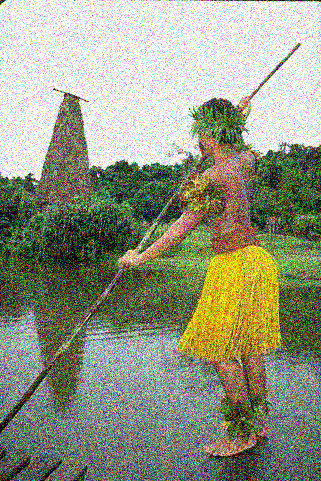

BLIP-2 Caption: A man in a grass skirt is standing in a body of water with a stick in his hand


In [8]:
noise_path = "/content/drive/MyDrive/VLU-Net-V2/datasets/denoising_datasets/CBSD68/noisy50/101087.png"
generate_blip_caption(noise_path)